In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/notjustauser/02-features/__results__.html
/kaggle/input/notebooks/notjustauser/02-features/smard_features.parquet
/kaggle/input/notebooks/notjustauser/02-features/feature_engineering_config.json
/kaggle/input/notebooks/notjustauser/02-features/__notebook__.ipynb
/kaggle/input/notebooks/notjustauser/02-features/__output__.json
/kaggle/input/notebooks/notjustauser/02-features/custom.css


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import( mean_absolute_error,mean_squared_error)

from pathlib import Path
import json

In [3]:
DATA_PATH = Path(
    "/kaggle/input/notebooks/notjustauser/"
    "02-features/smard_features.parquet"
)

LOOKBACK = 168
HORIZON = 24

OPERATIONAL_ORIGIN_HOUR_UTC = 12
CANONICAL_TIMEZONE = "UTC"
DISPLAY_TIMEZONE = "Europe/Berlin"

data = pd.read_parquet(DATA_PATH)

display(data.head())

,price_eur_mwh,load_actual_mwh,load_forecast_mwh,hour_sin,hour_cos,dow_sin,dow_cos,weekend,price_lag_1,price_lag_24,price_lag_48,price_lag_168,price_roll_mean_24,price_roll_std_24,price_roll_mean_168,price_roll_std_168,features_valid,forecast_load_available,actual_load_available,model_row_valid
timestamp,,,,,,,,,,,,,,,,,,,,
2022-08-31 19:00:00+00:00,677.26,54065.25,54673.50,-0.707107,0.707107,0.974928,-0.222521,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 20:00:00+00:00,563.52,50545.00,50893.75,-0.500000,0.866025,0.974928,-0.222521,0,677.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 21:00:00+00:00,532.51,46610.50,47281.75,-0.258819,0.965926,0.974928,-0.222521,0,563.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 22:00:00+00:00,490.77,43779.50,45334.25,0.000000,1.000000,0.433884,-0.900969,0,532.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 23:00:00+00:00,484.36,42271.75,43953.25,0.258819,0.965926,0.433884,-0.900969,0,490.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False


In [4]:
def validate_notebook2_input(frame):
    errors = []

    required_columns = {
        "price_eur_mwh",
        "load_actual_mwh",
        "load_forecast_mwh",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
        "weekend",
        "price_lag_1",
        "price_lag_24",
        "price_lag_48",
        "price_lag_168",
        "price_roll_mean_24",
        "price_roll_std_24",
        "price_roll_mean_168",
        "price_roll_std_168",
        "features_valid",
        "forecast_load_available",
    }

    missing_columns = required_columns.difference(
        frame.columns
    )

    if missing_columns:
        errors.append(
            "Missing Notebook 02 columns: "
            f"{sorted(missing_columns)}"
        )

    if not isinstance(frame.index, pd.DatetimeIndex):
        errors.append(
            "Notebook 02 must use a DatetimeIndex."
        )

    else:
        if frame.index.tz is None:
            errors.append(
                "Notebook 02 index is timezone-naive."
            )

        elif str(frame.index.tz) != CANONICAL_TIMEZONE:
            errors.append(
                f"Expected UTC index, found {frame.index.tz}."
            )

        if not frame.index.is_monotonic_increasing:
            errors.append(
                "Notebook 02 index is not sorted."
            )

        if frame.index.duplicated().any():
            errors.append(
                "Notebook 02 contains duplicate timestamps."
            )

        differences = (
            frame.index
            .to_series()
            .diff()
            .dropna()
        )

        non_hourly = differences[
            differences != pd.Timedelta(hours=1)
        ]

        if not non_hourly.empty:
            errors.append(
                f"Found {len(non_hourly)} non-hourly gaps."
            )

    if frame["price_eur_mwh"].isna().any():
        errors.append(
            "Target price contains missing values."
        )

    if not pd.api.types.is_numeric_dtype(
        frame["price_eur_mwh"]
    ):
        errors.append(
            "Target price is not numeric."
        )

    if errors:
        raise ValueError(
            "Notebook 02 input validation failed:\n- "
            + "\n- ".join(errors)
        )

    return {
        "rows": int(len(frame)),
        "columns": int(len(frame.columns)),
        "start_utc": frame.index.min(),
        "end_utc": frame.index.max(),
        "timezone": str(frame.index.tz),
        "price_missing": int(
            frame["price_eur_mwh"].isna().sum()
        ),
        "forecast_load_missing": int(
            frame["load_forecast_mwh"].isna().sum()
        ),
    }


notebook2_report = validate_notebook2_input(data)

display(
    pd.Series(
        notebook2_report,
        name="Notebook 02 input validation",
    )
)

rows                                         17568
columns                                         20
start_utc                2022-08-31 19:00:00+00:00
end_utc                  2024-09-01 18:00:00+00:00
timezone                                       UTC
price_missing                                    0
forecast_load_missing                           97
Name: Notebook 02 input validation, dtype: object

In [5]:
LOOKBACK = 168
HORIZON = 24

price = data["price_eur_mwh"].to_numpy(dtype=np.float32)

y_all = []
daily_all = []
weekly_all = []
target_start_times = []

for start in range(
    LOOKBACK,
    len(price) - HORIZON + 1
):

    y = price[
        start : start + HORIZON
    ]

    daily = price[
        start - 24 : start
    ]

    weekly = price[
        start - 168 : start - 168 + HORIZON
    ]

    if (
        y.shape == (HORIZON,)
        and daily.shape == (HORIZON,)
        and weekly.shape == (HORIZON,)
    ):
        y_all.append(y.copy())
        daily_all.append(daily.copy())
        weekly_all.append(weekly.copy())
        target_start_times.append(
            data.index[start]
        )

In [6]:
y_all = np.stack(y_all)
daily_all = np.stack(daily_all)
weekly_all = np.stack(weekly_all)

target_start_times = pd.DatetimeIndex(
    target_start_times
)

print(y_all.shape)
print(daily_all.shape)
print(weekly_all.shape)

(17377, 24)
(17377, 24)
(17377, 24)


In [7]:
expected_window_count = (
    len(data)
    - LOOKBACK
    - HORIZON
    + 1
)

if len(target_start_times) != expected_window_count:
    raise ValueError(
        "Unexpected number of baseline windows: "
        f"expected {expected_window_count}, "
        f"found {len(target_start_times)}."
    )

expected_shape = (
    expected_window_count,
    HORIZON,
)

for array_name, array in {
    "y_all": y_all,
    "daily_all": daily_all,
    "weekly_all": weekly_all,
}.items():
    if array.shape != expected_shape:
        raise ValueError(
            f"{array_name} has shape {array.shape}; "
            f"expected {expected_shape}."
        )

if target_start_times.tz is None:
    raise ValueError(
        "Forecast origins must be timezone-aware."
    )

if str(target_start_times.tz) != "UTC":
    raise ValueError(
        "Forecast origins must use UTC."
    )

if not target_start_times.is_monotonic_increasing:
    raise ValueError(
        "Forecast origins are not chronological."
    )

print("Baseline-window validation passed.")
print("Total windows:", expected_window_count)
print("First origin:", target_start_times[0])
print("Last origin:", target_start_times[-1])

Baseline-window validation passed.
Total windows: 17377
First origin: 2022-09-07 19:00:00+00:00
Last origin: 2024-08-31 19:00:00+00:00


In [8]:
n = len(target_start_times)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

In [9]:
train_idx = np.arange(0,train_end)

val_idx = np.arange(train_end,val_end)

test_idx = np.arange(val_end,n)

In [10]:
print("Train" ,target_start_times[train_idx[0]],"->",target_start_times[train_idx[-1]])
print("Validation" ,target_start_times[val_idx[0]],"->",target_start_times[val_idx[-1]])
print("Test" ,target_start_times[test_idx[0]],"->",target_start_times[test_idx[-1]])

Train 2022-09-07 19:00:00+00:00 -> 2024-01-27 13:00:00+00:00
Validation 2024-01-27 14:00:00+00:00 -> 2024-05-15 04:00:00+00:00
Test 2024-05-15 05:00:00+00:00 -> 2024-08-31 19:00:00+00:00


In [11]:
y_test = y_all[test_idx]
daily_test = daily_all[test_idx]
weekly_test = weekly_all[test_idx]
test_times = target_start_times[test_idx]
print(y_test.shape)
print(daily_test.shape)
print(weekly_test.shape)

(2607, 24)
(2607, 24)
(2607, 24)


In [12]:
# ============================================================
# OPERATIONAL 12:00 UTC TEST SUBSET
# ============================================================

operational_mask = (
    (test_times.hour == OPERATIONAL_ORIGIN_HOUR_UTC)
    & (test_times.minute == 0)
    & (test_times.second == 0)
)

operational_test_times = test_times[
    operational_mask
]

y_test_12utc = y_test[
    operational_mask
]

daily_test_12utc = daily_test[
    operational_mask
]

weekly_test_12utc = weekly_test[
    operational_mask
]

if len(operational_test_times) == 0:
    raise ValueError(
        "No 12:00 UTC forecast origins were found."
    )

expected_operational_shape = (
    len(operational_test_times),
    HORIZON,
)

for array_name, array in {
    "y_test_12utc": y_test_12utc,
    "daily_test_12utc": daily_test_12utc,
    "weekly_test_12utc": weekly_test_12utc,
}.items():
    if array.shape != expected_operational_shape:
        raise ValueError(
            f"{array_name} has shape {array.shape}; "
            f"expected {expected_operational_shape}."
        )

# Consecutive operational origins should normally be 24 elapsed
# hours apart because the job runs once per UTC day.
origin_differences = (
    operational_test_times
    .to_series()
    .diff()
    .dropna()
)

unexpected_differences = origin_differences[
    origin_differences
    != pd.Timedelta(hours=24)
]

if not unexpected_differences.empty:
    raise ValueError(
        "Operational origins are not exactly 24 hours apart."
    )

print(
    "Operational 12:00 UTC forecasts:",
    len(operational_test_times),
)

print(
    "First operational origin UTC:",
    operational_test_times[0],
)

print(
    "First operational origin Germany:",
    operational_test_times[0].tz_convert(
        DISPLAY_TIMEZONE
    ),
)

print(
    "Last operational origin UTC:",
    operational_test_times[-1],
)

Operational 12:00 UTC forecasts: 109
First operational origin UTC: 2024-05-15 12:00:00+00:00
First operational origin Germany: 2024-05-15 14:00:00+02:00
Last operational origin UTC: 2024-08-31 12:00:00+00:00


In [13]:
def smape(y_true,y_pred,eps = 1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    numerator = 2 * np.abs(y_pred-y_true)
    denominator = np.abs(y_true) + np.abs(y_pred) + eps
    return 100 * np.mean(numerator/denominator)


In [14]:
def evaluate_forecast(y_true, y_pred):

    true_flat = y_true.ravel()
    pred_flat = y_pred.ravel()

    mae = mean_absolute_error(
        true_flat,
        pred_flat
    )

    rmse = np.sqrt(
        mean_squared_error(
            true_flat,
            pred_flat
        )
    )

    score_smape = smape(
        true_flat,
        pred_flat
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": score_smape
    }

In [15]:
daily_metrics = evaluate_forecast(
    y_test,
    daily_test
)

daily_metrics



{'MAE': 27.346263885498047,
 'RMSE': np.float64(38.60978759643968),
 'sMAPE': np.float32(60.74255)}

In [16]:
weekly_metrics = evaluate_forecast(
    y_test,
    weekly_test
)

weekly_metrics

{'MAE': 27.33070945739746,
 'RMSE': np.float64(37.18577825583576),
 'sMAPE': np.float32(62.34175)}

In [17]:
baseline_results = pd.DataFrame(
    [
        {
            "model": "Daily seasonal naive (t-24)",
            **daily_metrics
        },
        {
            "model": "Weekly seasonal naive (t-168)",
            **weekly_metrics
        }
    ]
)

display(baseline_results)

,model,MAE,RMSE,sMAPE
0,Daily seasonal naive (t-24),27.346264,38.609788,60.742550
1,Weekly seasonal naive (t-168),27.330709,37.185778,62.341751


In [18]:
daily_metrics_12utc = evaluate_forecast(
    y_test_12utc,
    daily_test_12utc,
)

weekly_metrics_12utc = evaluate_forecast(
    y_test_12utc,
    weekly_test_12utc,
)

baseline_results_12utc = pd.DataFrame(
    [
        {
            "scope": "operational_12utc",
            "forecast_origin_hour_utc": (
                OPERATIONAL_ORIGIN_HOUR_UTC
            ),
            "model": (
                "Daily seasonal naive (t-24)"
            ),
            "forecast_count": int(
                len(operational_test_times)
            ),
            "target_instance_count": int(
                y_test_12utc.size
            ),
            **daily_metrics_12utc,
        },
        {
            "scope": "operational_12utc",
            "forecast_origin_hour_utc": (
                OPERATIONAL_ORIGIN_HOUR_UTC
            ),
            "model": (
                "Weekly seasonal naive (t-168)"
            ),
            "forecast_count": int(
                len(operational_test_times)
            ),
            "target_instance_count": int(
                y_test_12utc.size
            ),
            **weekly_metrics_12utc,
        },
    ]
)

display(baseline_results_12utc)

,scope,forecast_origin_hour_utc,model,forecast_count,target_instance_count,MAE,RMSE,sMAPE
0,operational_12utc,12,Daily seasonal naive (t-24),109,2616,27.337303,38.577041,60.844265
1,operational_12utc,12,Weekly seasonal naive (t-168),109,2616,27.396454,37.250587,62.567860


In [19]:
horizon_rows = []

for h in range(HORIZON):

    daily_mae = mean_absolute_error(
        y_test[:, h],
        daily_test[:, h]
    )

    weekly_mae = mean_absolute_error(
        y_test[:, h],
        weekly_test[:, h]
    )

    horizon_rows.append(
        {
            "horizon": h + 1,
            "daily_naive_mae": daily_mae,
            "weekly_naive_mae": weekly_mae
        }
    )

horizon_metrics = pd.DataFrame(
    horizon_rows
)

display(horizon_metrics)

,horizon,daily_naive_mae,weekly_naive_mae
0,1,27.350460,27.317535
1,2,27.347464,27.319416
2,3,27.337175,27.324619
3,4,27.326101,27.343571
4,5,27.329847,27.346621
5,6,27.333935,27.347061
6,7,27.331068,27.346394
7,8,27.324804,27.347208
8,9,27.320261,27.348776
9,10,27.324373,27.353571


In [20]:
operational_horizon_rows = []

for h in range(HORIZON):
    operational_horizon_rows.append(
        {
            "horizon": h + 1,
            "forecast_origin_hour_utc": (
                OPERATIONAL_ORIGIN_HOUR_UTC
            ),
            "daily_naive_mae": (
                mean_absolute_error(
                    y_test_12utc[:, h],
                    daily_test_12utc[:, h],
                )
            ),
            "weekly_naive_mae": (
                mean_absolute_error(
                    y_test_12utc[:, h],
                    weekly_test_12utc[:, h],
                )
            ),
        }
    )

baseline_horizon_metrics_12utc = pd.DataFrame(
    operational_horizon_rows
)

display(baseline_horizon_metrics_12utc)

,horizon,forecast_origin_hour_utc,daily_naive_mae,weekly_naive_mae
0,1,12,34.910828,35.425320
1,2,12,34.128532,34.358711
2,3,12,31.712109,31.190184
3,4,12,28.401831,31.682203
4,5,12,23.366238,26.357525
5,6,12,32.164497,33.628166
6,7,12,45.486332,37.824219
7,8,12,27.916697,26.427156
8,9,12,14.792661,17.214127
9,10,12,13.856514,15.984036


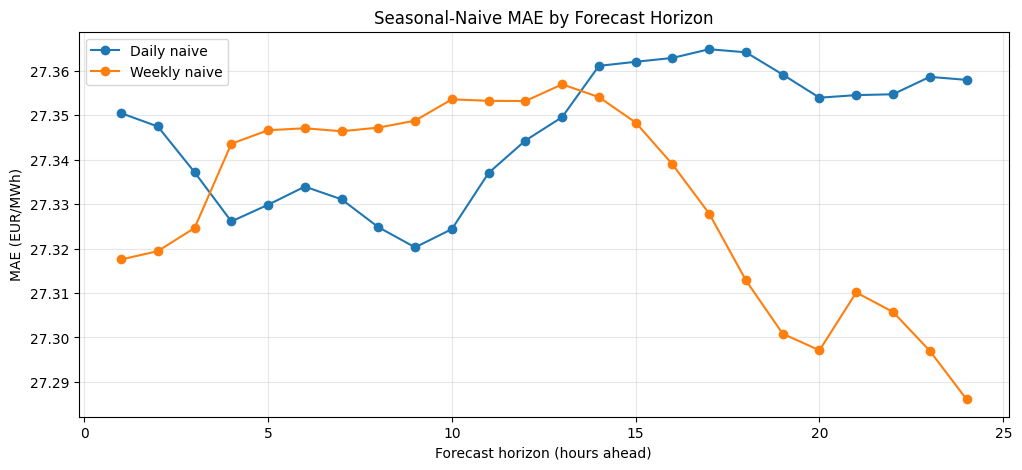

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    horizon_metrics["horizon"],
    horizon_metrics["daily_naive_mae"],
    marker="o",
    label="Daily naive"
)

plt.plot(
    horizon_metrics["horizon"],
    horizon_metrics["weekly_naive_mae"],
    marker="o",
    label="Weekly naive"
)

plt.xlabel("Forecast horizon (hours ahead)")
plt.ylabel("MAE (EUR/MWh)")
plt.title("Seasonal-Naive MAE by Forecast Horizon")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

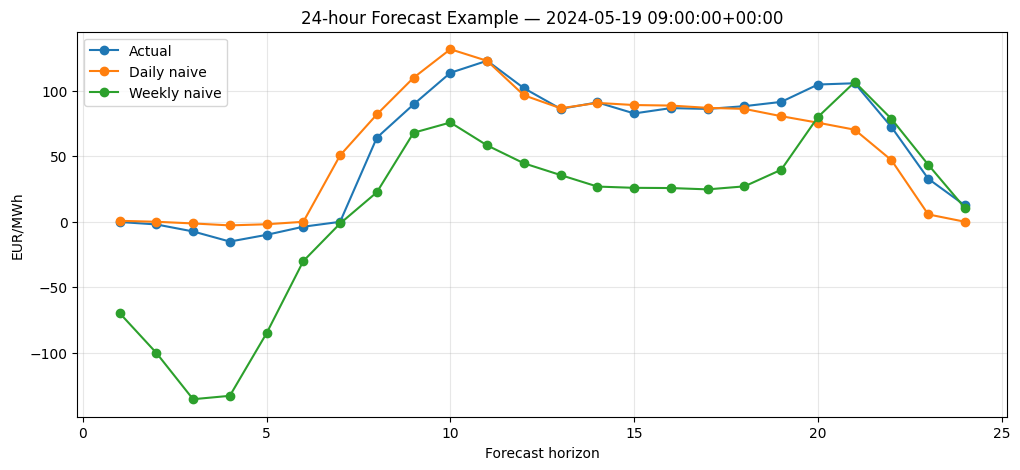

In [22]:
example = 100

hours = np.arange(1, 25)

plt.figure(figsize=(12, 5))

plt.plot(
    hours,
    y_test[example],
    marker="o",
    label="Actual"
)

plt.plot(
    hours,
    daily_test[example],
    marker="o",
    label="Daily naive"
)

plt.plot(
    hours,
    weekly_test[example],
    marker="o",
    label="Weekly naive"
)

plt.xlabel("Forecast horizon")
plt.ylabel("EUR/MWh")
plt.title(
    f"24-hour Forecast Example — "
    f"{test_times[example]}"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
actual_flat = y_test.ravel()
daily_flat = daily_test.ravel()
weekly_flat = weekly_test.ravel()

In [24]:
threshold = np.quantile(
    np.abs(actual_flat),
    0.95
)

extreme_mask = (
    np.abs(actual_flat) >= threshold
)

print(
    "Extreme threshold:",
    threshold
)

print(
    "Extreme observations:",
    extreme_mask.sum()
)

Extreme threshold: 139.0
Extreme observations: 3144


In [25]:
print(
    "Daily extreme MAE:",
    mean_absolute_error(
        actual_flat[extreme_mask],
        daily_flat[extreme_mask]
    )
)

print(
    "Weekly extreme MAE:",
    mean_absolute_error(
        actual_flat[extreme_mask],
        weekly_flat[extreme_mask]
    )
)

Daily extreme MAE: 51.61748123168945
Weekly extreme MAE: 40.43098831176758


In [26]:
negative_mask = actual_flat < 0

print(
    "Negative-price observations:",
    negative_mask.sum()
)

Negative-price observations: 5763


In [27]:
if negative_mask.sum() > 0:

    print(
        "Daily negative-price MAE:",
        mean_absolute_error(
            actual_flat[negative_mask],
            daily_flat[negative_mask]
        )
    )

    print(
        "Weekly negative-price MAE:",
        mean_absolute_error(
            actual_flat[negative_mask],
            weekly_flat[negative_mask]
        )
    )

Daily negative-price MAE: 34.082908630371094
Weekly negative-price MAE: 38.142723083496094


In [28]:
split_config = {
    "lookback_hours": LOOKBACK,
    "forecast_horizon_hours": HORIZON,

    "split_method": "chronological_70_15_15",

    "train_first_target":
        str(target_start_times[train_idx[0]]),

    "train_last_target":
        str(target_start_times[train_idx[-1]]),

    "validation_first_target":
        str(target_start_times[val_idx[0]]),

    "validation_last_target":
        str(target_start_times[val_idx[-1]]),

    "test_first_target":
        str(target_start_times[test_idx[0]]),

    "test_last_target":
        str(target_start_times[test_idx[-1]])
}

In [29]:
split_config

{'lookback_hours': 168,
 'forecast_horizon_hours': 24,
 'split_method': 'chronological_70_15_15',
 'train_first_target': '2022-09-07 19:00:00+00:00',
 'train_last_target': '2024-01-27 13:00:00+00:00',
 'validation_first_target': '2024-01-27 14:00:00+00:00',
 'validation_last_target': '2024-05-15 04:00:00+00:00',
 'test_first_target': '2024-05-15 05:00:00+00:00',
 'test_last_target': '2024-08-31 19:00:00+00:00'}

In [30]:
with open(
    "/kaggle/working/split_config.json",
    "w"
) as f:

    json.dump(
        split_config,
        f,
        indent=4
    )

In [31]:
baseline_results.to_csv(
    "/kaggle/working/baseline_metrics.csv",
    index=False
)

In [32]:
horizon_metrics.to_csv(
    "/kaggle/working/baseline_horizon_metrics.csv",
    index=False
)

In [33]:
records = []

for i in range(len(y_test)):

    for h in range(HORIZON):

        records.append(
            {
                "forecast_start": test_times[i],
                "horizon": h + 1,
                "actual": y_test[i, h],
                "daily_naive": daily_test[i, h],
                "weekly_naive": weekly_test[i, h]
            }
        )

In [34]:
baseline_predictions = pd.DataFrame(
    records
)

display(
    baseline_predictions.head()
)

,forecast_start,horizon,actual,daily_naive,weekly_naive
0,2024-05-15 05:00:00+00:00,1,88.160004,77.330002,118.959999
1,2024-05-15 05:00:00+00:00,2,84.449997,51.500000,110.120003
2,2024-05-15 05:00:00+00:00,3,48.419998,5.640000,92.410004
3,2024-05-15 05:00:00+00:00,4,7.360000,-2.330000,85.400002
4,2024-05-15 05:00:00+00:00,5,-0.080000,-11.120000,79.480003


In [35]:
baseline_predictions.to_parquet(
    "/kaggle/working/baseline_predictions.parquet",
    index=False
)

In [36]:
operational_records = []

for forecast_index in range(
    len(operational_test_times)
):
    forecast_origin_utc = pd.Timestamp(
        operational_test_times[forecast_index]
    )

    forecast_origin_germany = (
        forecast_origin_utc.tz_convert(
            DISPLAY_TIMEZONE
        )
    )

    for h in range(HORIZON):
        delivery_time_utc = (
            forecast_origin_utc
            + pd.Timedelta(hours=h)
        )

        delivery_time_germany = (
            delivery_time_utc.tz_convert(
                DISPLAY_TIMEZONE
            )
        )

        actual_value = float(
            y_test_12utc[forecast_index, h]
        )

        daily_value = float(
            daily_test_12utc[forecast_index, h]
        )

        weekly_value = float(
            weekly_test_12utc[forecast_index, h]
        )

        operational_records.append(
            {
                "forecast_start_utc": (
                    forecast_origin_utc
                ),
                "forecast_start_germany": (
                    forecast_origin_germany
                ),
                "delivery_time_utc": (
                    delivery_time_utc
                ),
                "delivery_time_germany": (
                    delivery_time_germany
                ),
                "german_timezone_abbreviation": (
                    delivery_time_germany.tzname()
                ),
                "german_utc_offset_hours": (
                    delivery_time_germany
                    .utcoffset()
                    .total_seconds()
                    / 3600
                ),
                "horizon": h + 1,
                "actual": actual_value,
                "daily_naive": daily_value,
                "weekly_naive": weekly_value,
                "daily_absolute_error": abs(
                    actual_value - daily_value
                ),
                "weekly_absolute_error": abs(
                    actual_value - weekly_value
                ),
            }
        )


baseline_predictions_12utc = pd.DataFrame(
    operational_records
)

display(baseline_predictions_12utc.head())

,forecast_start_utc,forecast_start_germany,delivery_time_utc,delivery_time_germany,german_timezone_abbreviation,german_utc_offset_hours,horizon,actual,daily_naive,weekly_naive,daily_absolute_error,weekly_absolute_error
0,2024-05-15 12:00:00+00:00,2024-05-15 14:00:00+02:00,2024-05-15 12:00:00+00:00,2024-05-15 14:00:00+02:00,CEST,2.0,1,-9.910000,-39.660000,66.580002,29.750000,76.490002
1,2024-05-15 12:00:00+00:00,2024-05-15 14:00:00+02:00,2024-05-15 13:00:00+00:00,2024-05-15 15:00:00+02:00,CEST,2.0,2,-0.090000,-19.860001,66.949997,19.770001,67.039997
2,2024-05-15 12:00:00+00:00,2024-05-15 14:00:00+02:00,2024-05-15 14:00:00+00:00,2024-05-15 16:00:00+02:00,CEST,2.0,3,1.730000,-2.930000,75.720001,4.660000,73.990001
3,2024-05-15 12:00:00+00:00,2024-05-15 14:00:00+02:00,2024-05-15 15:00:00+00:00,2024-05-15 17:00:00+02:00,CEST,2.0,4,30.330000,-0.040000,91.099998,30.370000,60.769999
4,2024-05-15 12:00:00+00:00,2024-05-15 14:00:00+02:00,2024-05-15 16:00:00+00:00,2024-05-15 18:00:00+02:00,CEST,2.0,5,73.660004,43.740002,106.500000,29.920002,32.839996


In [37]:
OPERATIONAL_METRICS_PATH = Path(
    "/kaggle/working/"
    "baseline_metrics_12utc.csv"
)

OPERATIONAL_HORIZON_PATH = Path(
    "/kaggle/working/"
    "baseline_horizon_metrics_12utc.csv"
)

OPERATIONAL_PREDICTIONS_PATH = Path(
    "/kaggle/working/"
    "baseline_predictions_12utc.parquet"
)

OPERATIONAL_CONFIG_PATH = Path(
    "/kaggle/working/"
    "operational_baseline_config.json"
)


expected_prediction_rows = (
    len(operational_test_times)
    * HORIZON
)

if (
    len(baseline_predictions_12utc)
    != expected_prediction_rows
):
    raise ValueError(
        "Operational prediction row count mismatch: "
        f"expected {expected_prediction_rows}, "
        f"found {len(baseline_predictions_12utc)}."
    )

if baseline_predictions_12utc[
    "delivery_time_utc"
].duplicated().any():
    raise ValueError(
        "The once-daily operational forecasts contain "
        "duplicate UTC delivery timestamps."
    )


baseline_results_12utc.to_csv(
    OPERATIONAL_METRICS_PATH,
    index=False,
)

baseline_horizon_metrics_12utc.to_csv(
    OPERATIONAL_HORIZON_PATH,
    index=False,
)

baseline_predictions_12utc.to_parquet(
    OPERATIONAL_PREDICTIONS_PATH,
    index=False,
)


operational_config = {
    "scope": "operational_12utc_baselines",
    "forecast_origin_hour_utc": (
        OPERATIONAL_ORIGIN_HOUR_UTC
    ),
    "forecast_horizon_hours": HORIZON,
    "display_timezone": DISPLAY_TIMEZONE,
    "forecast_count": int(
        len(operational_test_times)
    ),
    "first_forecast_origin_utc": (
        operational_test_times[0].isoformat()
    ),
    "last_forecast_origin_utc": (
        operational_test_times[-1].isoformat()
    ),
    "metrics": [
        "MAE",
        "RMSE",
        "sMAPE",
    ],
    "original_experiment_preserved": True,
    "original_split_method": (
        "chronological_70_15_15"
    ),
    "known_methodological_limitation": (
        "The frozen experiment uses overlapping hourly forecast "
        "origins and assigns splits by target-start timestamp. "
        "Changing this now would require retraining all models."
    ),
}

with OPERATIONAL_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        operational_config,
        file,
        indent=2,
    )


# Reload checks

reloaded_operational_predictions = (
    pd.read_parquet(
        OPERATIONAL_PREDICTIONS_PATH
    )
)

if (
    len(reloaded_operational_predictions)
    != expected_prediction_rows
):
    raise ValueError(
        "Saved operational predictions failed verification."
    )

print("Saved operational baseline artifacts:")
print(OPERATIONAL_METRICS_PATH)
print(OPERATIONAL_HORIZON_PATH)
print(OPERATIONAL_PREDICTIONS_PATH)
print(OPERATIONAL_CONFIG_PATH)

Saved operational baseline artifacts:
/kaggle/working/baseline_metrics_12utc.csv
/kaggle/working/baseline_horizon_metrics_12utc.csv
/kaggle/working/baseline_predictions_12utc.parquet
/kaggle/working/operational_baseline_config.json
